for this activity, we explore the music tastes of Africans, by suing the the  Spotify dataset with information on the audio features of some songs made by Nigerians!

the dataset reference:
https://www.kaggle.com/sootersaalu/nigerian-songs-spotify


In [1]:
# [本機改寫] 原 cell 為 Colab 專用:
#   from google.colab import drive
#   drive.mount('/content/gdrive'); %cd gdrive/ ; %cd MyDrive/
# 本機 Anaconda/Jupyter 不需掛載雲端硬碟,只要 nigerian_spotify_songs1.csv
# 與本 notebook 在同一資料夾即可。
%matplotlib inline


In [2]:
import pandas as pd
df= pd.read_csv('nigerian_spotify_songs1.csv')
df.head()

,name,album,artist,artist_top_genre,release_date,length,popularity,danceability,acousticness,energy,instrumentalness,liveness,loudness,speechiness,tempo,time_signature
0,Sparky,Mandy & The Jungle,Cruel Santino,alternative r&b,2019,144000,48,0.666,0.8510,0.420,0.534000,0.1100,-6.699,0.0829,133.015,5
1,shuga rush,EVERYTHING YOU HEARD IS TRUE,Odunsi (The Engine),afropop,2020,89488,30,0.710,0.0822,0.683,0.000169,0.1010,-5.640,0.3600,129.993,3
2,LITT!,LITT!,AYLØ,indie r&b,2018,207758,40,0.836,0.2720,0.564,0.000537,0.1100,-7.127,0.0424,130.005,4
3,Confident / Feeling Cool,Enjoy Your Life,Lady Donli,nigerian pop,2019,175135,14,0.894,0.7980,0.611,0.000187,0.0964,-4.961,0.1130,111.087,4
4,wanted you,rare.,Odunsi (The Engine),afropop,2018,152049,25,0.702,0.1160,0.833,0.910000,0.3480,-6.044,0.0447,105.115,4


you can get more information of the dataset:

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 530 entries, 0 to 529
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              530 non-null    str    
 1   album             530 non-null    str    
 2   artist            530 non-null    str    
 3   artist_top_genre  530 non-null    str    
 4   release_date      530 non-null    int64  
 5   length            530 non-null    int64  
 6   popularity        530 non-null    int64  
 7   danceability      530 non-null    float64
 8   acousticness      530 non-null    float64
 9   energy            530 non-null    float64
 10  instrumentalness  530 non-null    float64
 11  liveness          530 non-null    float64
 12  loudness          530 non-null    float64
 13  speechiness       530 non-null    float64
 14  tempo             530 non-null    float64
 15  time_signature    530 non-null    int64  
dtypes: float64(8), int64(4), str(4)
memory usage: 66.4 KB


also you may make sure there is not null values:

In [4]:
df.isnull().sum()

name                0
album               0
artist              0
artist_top_genre    0
release_date        0
length              0
popularity          0
danceability        0
acousticness        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
time_signature      0
dtype: int64

and get some basic statistical information on the dataset!

In [5]:
df.describe()

,release_date,length,popularity,danceability,acousticness,energy,instrumentalness,liveness,loudness,speechiness,tempo,time_signature
count,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000
mean,2015.390566,222298.169811,17.507547,0.741619,0.265412,0.760623,0.016305,0.147308,-4.953011,0.130748,116.487864,3.986792
std,3.131688,39696.822259,18.992212,0.117522,0.208342,0.148533,0.090321,0.123588,2.464186,0.092939,23.518601,0.333701
min,1998.000000,89488.000000,0.000000,0.255000,0.000665,0.111000,0.000000,0.028300,-19.362000,0.027800,61.695000,3.000000
25%,2014.000000,199305.000000,0.000000,0.681000,0.089525,0.669000,0.000000,0.075650,-6.298750,0.059100,102.961250,4.000000
50%,2016.000000,218509.000000,13.000000,0.761000,0.220500,0.784500,0.000004,0.103500,-4.558500,0.097950,112.714500,4.000000
75%,2017.000000,242098.500000,31.000000,0.829500,0.403000,0.875750,0.000234,0.164000,-3.331000,0.177000,125.039250,4.000000
max,2020.000000,511738.000000,73.000000,0.966000,0.954000,0.995000,0.910000,0.811000,0.582000,0.514000,206.007000,5.000000


you can also find the most popular genres using a barplot:

Text(0.5, 1.0, 'Top genres')

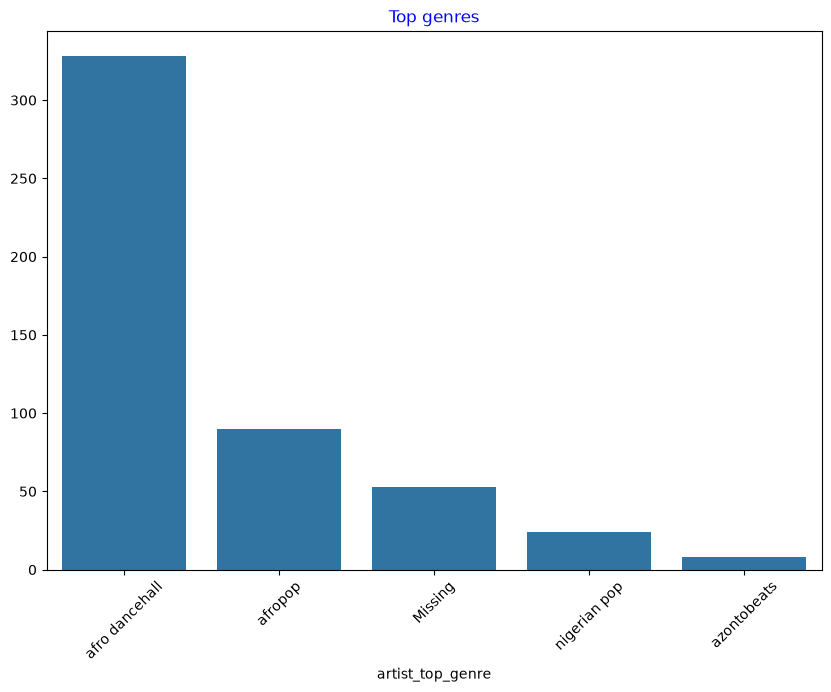

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
top = df['artist_top_genre'].value_counts()
plt.figure(figsize=(10,7))
sns.barplot(x=top[:5].index,y=top[:5].values)
plt.xticks(rotation=45)
plt.title('Top genres',color = 'blue')

cosndiering that third most popular genre is "Missing", you should delete it since Spotify did not provide classification for them:

Text(0.5, 1.0, 'Top genres')

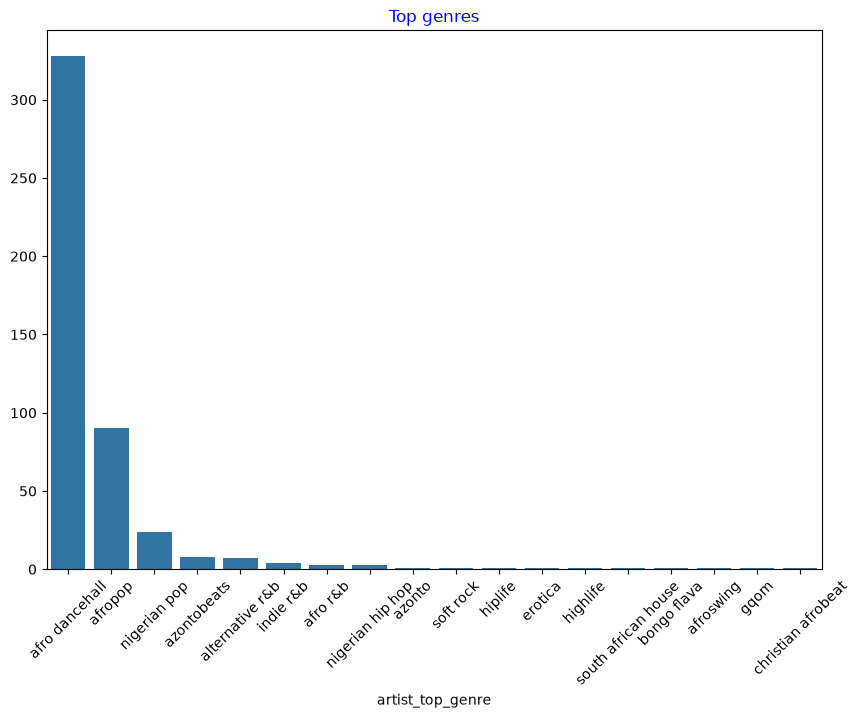

In [7]:
df = df[df['artist_top_genre'] != 'Missing']
top = df['artist_top_genre'].value_counts()
plt.figure(figsize=(10,7))
sns.barplot(x=top.index,y=top.values)
plt.xticks(rotation=45)
plt.title('Top genres',color = 'blue')

as you see in the barchart, the top three genres dominate others genres! : (1) afro dancehall, (2) afropop, and (3) nigerian pop

Text(0.5, 1.0, 'Top genres')

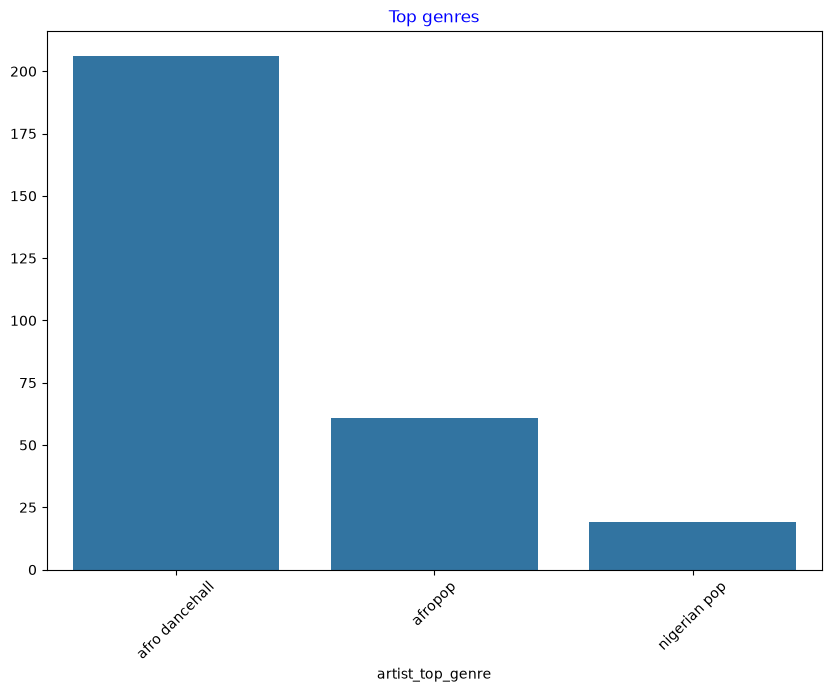

In [8]:
df = df[(df['artist_top_genre'] == 'afro dancehall') | (df['artist_top_genre'] == 'afropop') | (df['artist_top_genre'] == 'nigerian pop')]
df = df[(df['popularity'] > 0)]
top = df['artist_top_genre'].value_counts()
plt.figure(figsize=(10,7))
sns.barplot(x=top.index,y=top.values)
plt.xticks(rotation=45)
plt.title('Top genres',color = 'blue')

You can use heatmap to find out whether there are any strong colloretaion or not:

<Axes: >

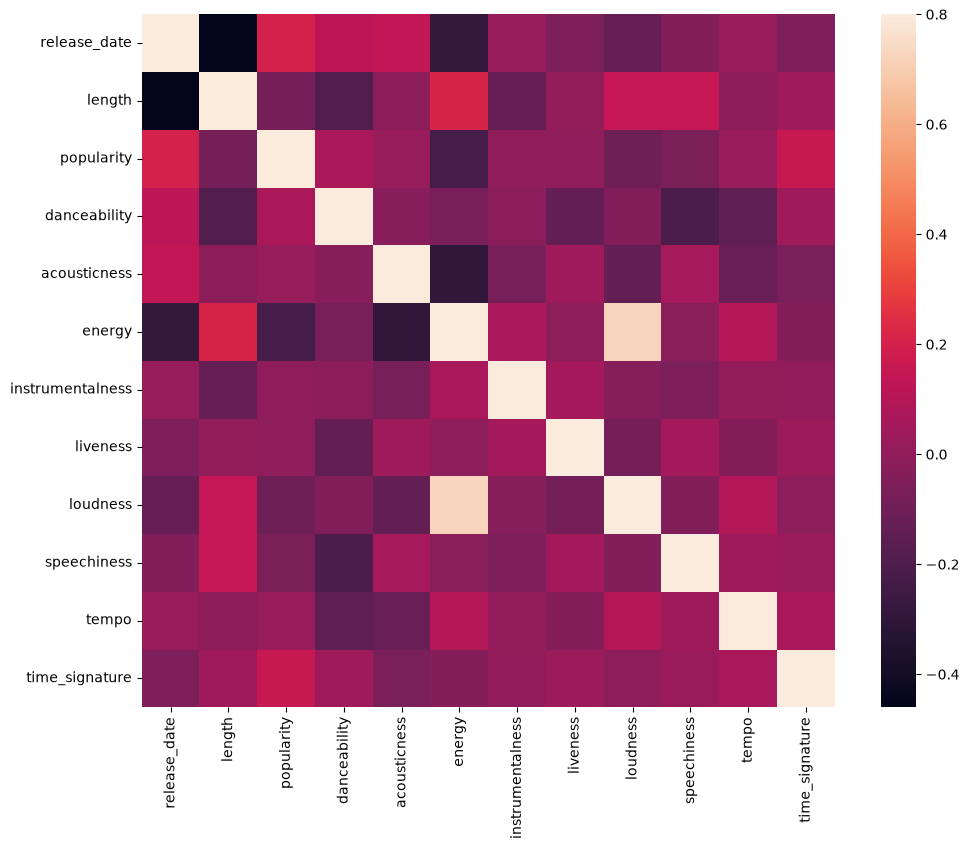

In [9]:
df_numeric = df.select_dtypes(include=['number'])
corrmat = df_numeric.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True)

there is just one strong correlation: between "energy" and "loudness", which makes sense!

lets find out that "are these three genres significantly different in the perception of their danceability, based on their popularity?

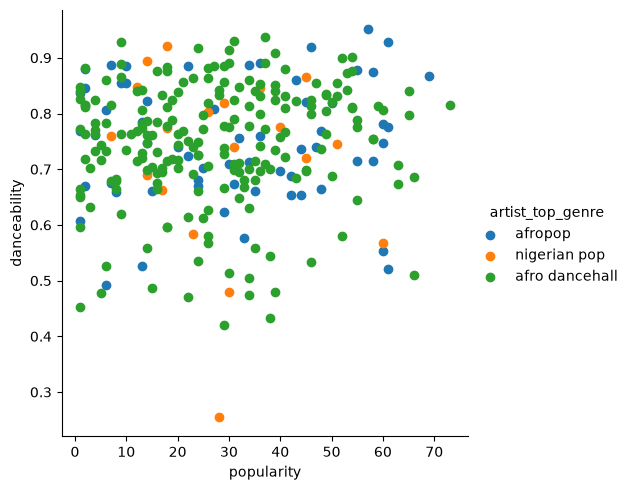

In [10]:
sns.FacetGrid(df, hue="artist_top_genre", height=5) \
   .map(plt.scatter, "popularity", "danceability") \
   .add_legend()

as you see, the three genres align loosely in terms of their popularity and danceability. Now we run the K-means.

We use below features for clustering :

In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

X = df.loc[:, ('artist_top_genre','popularity','danceability','acousticness','loudness','energy')]

y = df['artist_top_genre']

X['artist_top_genre'] = le.fit_transform(X['artist_top_genre'])

y = le.transform(y)

So lets use k=3 :

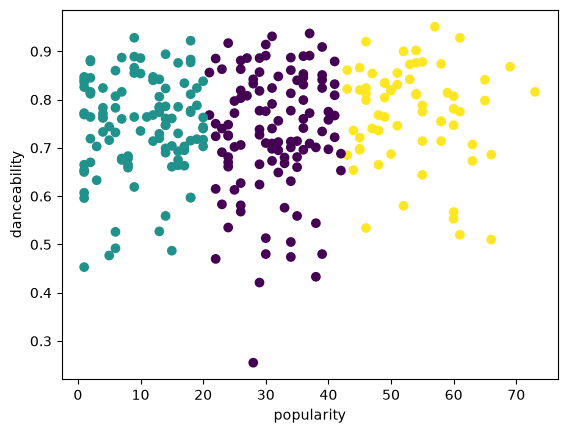

In [12]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 3,n_init=10)
kmeans.fit(X)
labels = kmeans.predict(X)
plt.scatter(df['popularity'],df['danceability'],c = labels)
plt.xlabel('popularity')
plt.ylabel('danceability')
plt.show()

we can also use the silhouette score to see wether k=3 is a good selection or not!

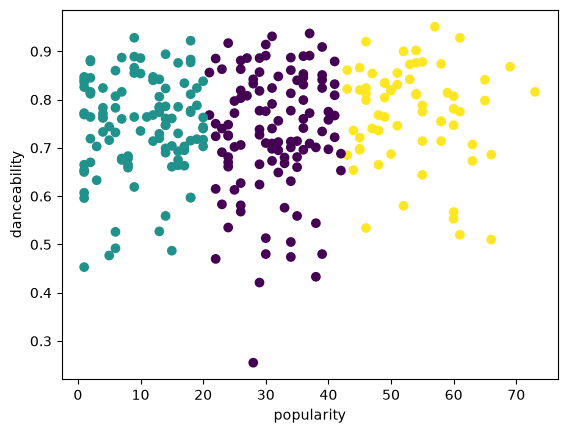

In [13]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 3,n_init=10)
kmeans.fit(X)
labels = kmeans.predict(X)
plt.scatter(df['popularity'],df['danceability'],c = labels)
plt.xlabel('popularity')
plt.ylabel('danceability')
plt.show()

In [14]:
from sklearn.metrics import silhouette_score
range_n_clusters = [2, 3, 4, 5, 6, 7,8,9]
for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters=n_clusters,n_init=10, random_state=10)
    cluster_labels = clusterer.fit_predict(X)
    silhouette_avg = silhouette_score(X, cluster_labels)
    print("For n_clusters =", n_clusters,
          "The average silhouette_score is :", silhouette_avg)

For n_clusters = 2 The average silhouette_score is : 0.5628313330897252
For n_clusters = 3 The average silhouette_score is : 0.5466747351275563
For n_clusters = 4 The average silhouette_score is : 0.5000498069451838
For n_clusters = 5 The average silhouette_score is : 0.47866538735482017
For n_clusters = 6 The average silhouette_score is : 0.4587279298676154
For n_clusters = 7 The average silhouette_score is : 0.4243486216192151
For n_clusters = 8 The average silhouette_score is : 0.394849233256404
For n_clusters = 9 The average silhouette_score is : 0.38591552574287885
